# 218 -- k-mer spectra across HP alphabets, ksizes, on order-2/order-3 shuffled Swiss-Prot

`nextflow-runs/kmer-spectra` ran `kmerseek index --stats-only` over the 7 HP-family alphabets
(`hp`, `hp_kyte_doolittle`, `hp_lehninger_plus_c`, `hp_pbotc_1st_ed`, `hp_shuffled_control`,
`hp_thomas_dill`, `hp_thomas_dill_no_c`) and ksize 15-30, on two null controls built by shuffling
Swiss-Prot. `k2` preserves the amino-acid composition and local dipeptide (order-2) statistics of
the real sequences and scrambles everything else; `k3` does the same at the tripeptide (order-3)
level. Both are shuffles of the sequence itself. That's different from the `hp_shuffled_control`
alphabet, which keeps real protein sequences and instead randomizes which amino acids map to H
and which map to P (see `README-sherlock.md`).

Each `*.spectrum.csv.gz` file is a k-mer frequency histogram: for one (dataset, alphabet, ksize)
combination, how many distinct k-mers occurred exactly N times across the whole proteome, plus a
one-line summary (`total_kmers`, `unique_kmers`, `mean_seqs_per_kmer`, `median_seqs_per_kmer`).
This notebook asks two questions:

1. How different are the two null controls from each other? (Section 1)
2. At what ksize does real Swiss-Prot's spectrum start to look different from these nulls, and
   what does that difference mean for choosing a minimum ksize? (Section 2)

In [1]:
from __future__ import annotations

import gzip
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from scipy.spatial.distance import jensenshannon

RESULTS_ROOT = Path("/Users/olga/data")
DATASETS = ["k2", "k3"]
DATASET_LABELS = {"k2": "order-2 shuffled (k2)", "k3": "order-3 shuffled (k3)"}

# Fixed hue order across every figure in this notebook -- never re-cycled per subset.
ALPHABET_COLORS = {
    "hp": "#4C72B0",
    "hp_kyte_doolittle": "#DD8452",
    "hp_lehninger_plus_c": "#55A868",
    "hp_pbotc_1st_ed": "#C44E52",
    "hp_shuffled_control": "#8C8C8C",
    "hp_thomas_dill": "#8172B2",
    "hp_thomas_dill_no_c": "#CCB974",
}
ALPHABETS = list(ALPHABET_COLORS)


In [2]:
HEADER_RE = re.compile(
    r"total_kmers=(?P<total_kmers>\d+)\s+"
    r"unique_kmers=(?P<unique_kmers>\d+)\s+"
    r"mean_seqs_per_kmer=(?P<mean_seqs_per_kmer>[\d.]+)\s+"
    r"median_seqs_per_kmer=(?P<median_seqs_per_kmer>[\d.]+)\s+"
    r"moltype=(?P<moltype>\S+)\s+"
    r"ksize=(?P<ksize>\d+)"
)


def load_spectrum_file(path: Path, dataset: str) -> tuple[dict, pl.DataFrame]:
    with gzip.open(path, "rt") as fh:
        header_line = fh.readline()
    m = HEADER_RE.search(header_line)
    if m is None:
        raise ValueError(f"Could not parse header in {path}: {header_line!r}")
    summary = {
        "dataset": dataset,
        "moltype": m["moltype"],
        "ksize": int(m["ksize"]),
        "total_kmers": int(m["total_kmers"]),
        "unique_kmers": int(m["unique_kmers"]),
        "mean_seqs_per_kmer": float(m["mean_seqs_per_kmer"]),
        "median_seqs_per_kmer": float(m["median_seqs_per_kmer"]),
    }
    body = pl.read_csv(path, comment_prefix="#")
    body = body.with_columns(pl.lit(dataset).alias("dataset"))
    return summary, body


def spectrum_jsd(alphabet: str, ksize: int, dataset_a: str, dataset_b: str, all_df: pl.DataFrame) -> float:
    """Jensen-Shannon distance between two datasets' occurrence-count spectra at one
    (alphabet, ksize): 0 = identical shape, 1 = maximally different. Each spectrum is
    normalized to a probability distribution over "how many times does a randomly
    chosen unique k-mer occur" before comparing, so it's a shape comparison, not a
    scale comparison."""
    a = all_df.filter((pl.col("moltype") == alphabet) & (pl.col("ksize") == ksize) & (pl.col("dataset") == dataset_a))
    b = all_df.filter((pl.col("moltype") == alphabet) & (pl.col("ksize") == ksize) & (pl.col("dataset") == dataset_b))
    joined = (
        a.select("occurrences", pl.col("n_kmers").alias("n_a"))
        .join(b.select("occurrences", pl.col("n_kmers").alias("n_b")), on="occurrences", how="full", coalesce=True)
        .fill_null(0)
    )
    p = joined["n_a"].to_numpy()
    q = joined["n_b"].to_numpy()
    p = p / p.sum()
    q = q / q.sum()
    return float(jensenshannon(p, q, base=2))


summaries = []
spectra = []
for dataset in DATASETS:
    result_dir = RESULTS_ROOT / f"kmerseek-kmer-spectra-ushuffle-{dataset}"
    files = sorted(result_dir.glob(f"{dataset}.*.spectrum.csv.gz"))
    for f in files:
        summary, body = load_spectrum_file(f, dataset)
        summaries.append(summary)
        spectra.append(body)

summary_df = pl.DataFrame(summaries).sort(["dataset", "moltype", "ksize"])
spectra_df = pl.concat(spectra).sort(["dataset", "moltype", "ksize", "occurrences"])
KSIZES = sorted(spectra_df["ksize"].unique().to_list())

print(f"summary_df: {summary_df.height} (dataset, alphabet, ksize) combos")
print(f"spectra_df: {spectra_df.height:,} histogram rows")
summary_df.head(10)


summary_df: 224 (dataset, alphabet, ksize) combos
spectra_df: 392,119 histogram rows


dataset,moltype,ksize,total_kmers,unique_kmers,mean_seqs_per_kmer,median_seqs_per_kmer
str,str,i64,i64,i64,f64,f64
"""k2""","""hp""",15,196771645,80907,2432.0719,1.0
"""k2""","""hp""",16,197513144,118200,1671.008,2377.0
"""k2""","""hp""",17,197644939,187453,1054.3706,1263.0
"""k2""","""hp""",18,197448783,321696,613.7744,653.0
"""k2""","""hp""",19,197078790,586665,335.9307,333.0
"""k2""","""hp""",20,196616771,1113579,176.5629,168.0
"""k2""","""hp""",21,196105776,2164650,90.5947,85.0
"""k2""","""hp""",22,195568906,4264251,45.8624,43.0
"""k2""","""hp""",23,195018399,8460917,23.0493,21.0


## Section 1 -- the null controls: how different are k2 and k3?

`unique_kmers` is the number of distinct k-mers seen at all; `mean_seqs_per_kmer` is
`total_kmers / unique_kmers`, the average number of times each distinct k-mer recurs. Both
should move the same way with ksize on any null: short k-mers are heavily repeated because the
k-mer vocabulary is small, and as ksize grows the vocabulary outgrows the proteome and almost
every k-mer becomes unique.

One alphabet-specific note: each HP alphabet is a strict binary H/P partition of the 20
canonical amino acids, so the nominal vocabulary at ksize k is 2^k. But `unique_kmers` at k=15
already exceeds 2^15 -- kmerseek passes non-standard residues and stop codons (`*`) through the
H/P encoding unchanged instead of folding them into h or p, so the real vocabulary is a bit
larger than the nominal 2-letter alphabet implies.

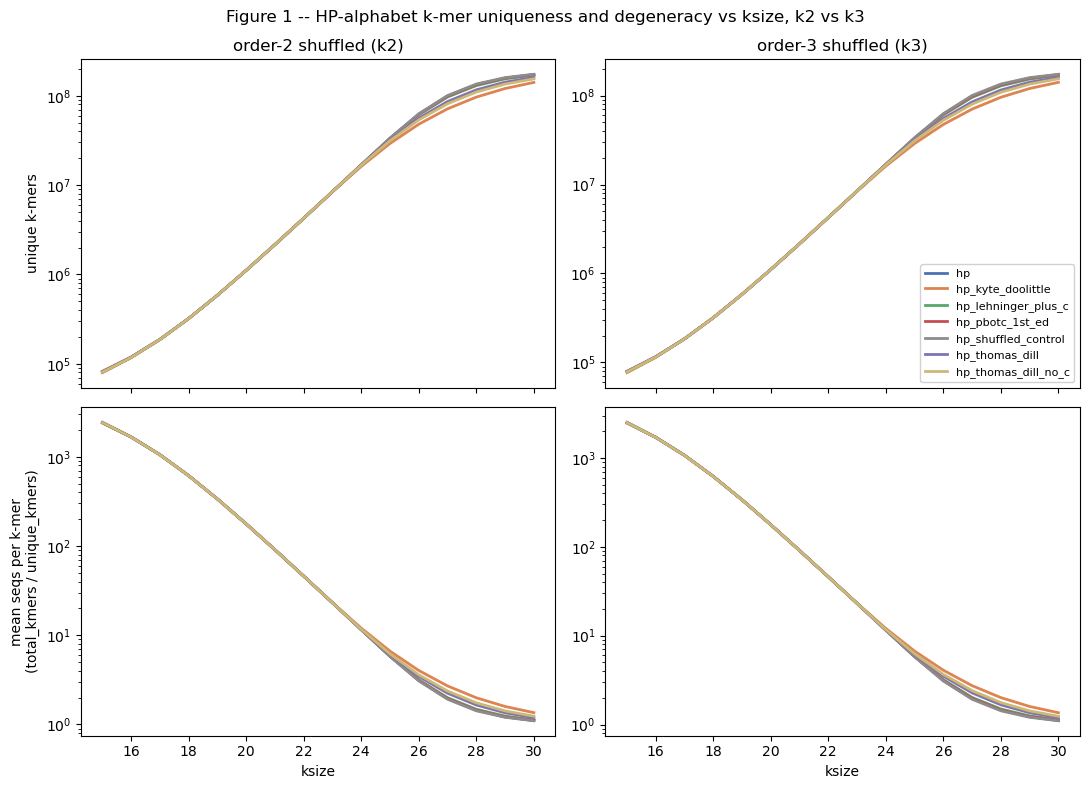

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)

for col, dataset in enumerate(DATASETS):
    sub = summary_df.filter(pl.col("dataset") == dataset)
    ax_unique, ax_mean = axes[0, col], axes[1, col]
    for alphabet in ALPHABETS:
        a = sub.filter(pl.col("moltype") == alphabet).sort("ksize")
        color = ALPHABET_COLORS[alphabet]
        ax_unique.plot(a["ksize"], a["unique_kmers"], color=color, lw=2, label=alphabet)
        ax_mean.plot(a["ksize"], a["mean_seqs_per_kmer"], color=color, lw=2, label=alphabet)
    ax_unique.set_yscale("log")
    ax_mean.set_yscale("log")
    ax_unique.set_title(DATASET_LABELS[dataset])
    ax_mean.set_xlabel("ksize")

axes[0, 0].set_ylabel("unique k-mers")
axes[1, 0].set_ylabel("mean seqs per k-mer\n(total_kmers / unique_kmers)")
axes[0, 1].legend(loc="lower right", fontsize=8, framealpha=0.9)

fig.suptitle("Figure 1 -- HP-alphabet k-mer uniqueness and degeneracy vs ksize, k2 vs k3")
fig.tight_layout()
fig.savefig("/tmp/nb218_fig1_unique_and_degeneracy.png", dpi=150)


In [4]:
at_k15 = summary_df.filter(pl.col("ksize") == 15).select(
    "dataset", "moltype", "unique_kmers", "mean_seqs_per_kmer"
).sort(["dataset", "mean_seqs_per_kmer"], descending=[False, True])
print("At ksize=15 (the HP-family floor used elsewhere in this project):")
at_k15


At ksize=15 (the HP-family floor used elsewhere in this project):


dataset,moltype,unique_kmers,mean_seqs_per_kmer
str,str,i64,f64
"""k2""","""hp""",80907,2432.0719
"""k2""","""hp_kyte_doolittle""",79531,2429.6437
"""k2""","""hp_thomas_dill_no_c""",80601,2414.9468
"""k2""","""hp_lehninger_plus_c""",81458,2413.8745
"""k2""","""hp_thomas_dill""",81216,2405.8596
…,…,…,…
"""k3""","""hp_lehninger_plus_c""",78767,2490.3207
"""k3""","""hp_thomas_dill_no_c""",78151,2486.0595
"""k3""","""hp_thomas_dill""",78710,2477.5258


Figure 1 puts every alphabet within a narrow band on both k2 and k3 -- the lines are hard to
tell apart by eye. Figure 2 checks the same thing at full resolution: not just the mean, but the
whole occurrence-count histogram, one line per ksize.

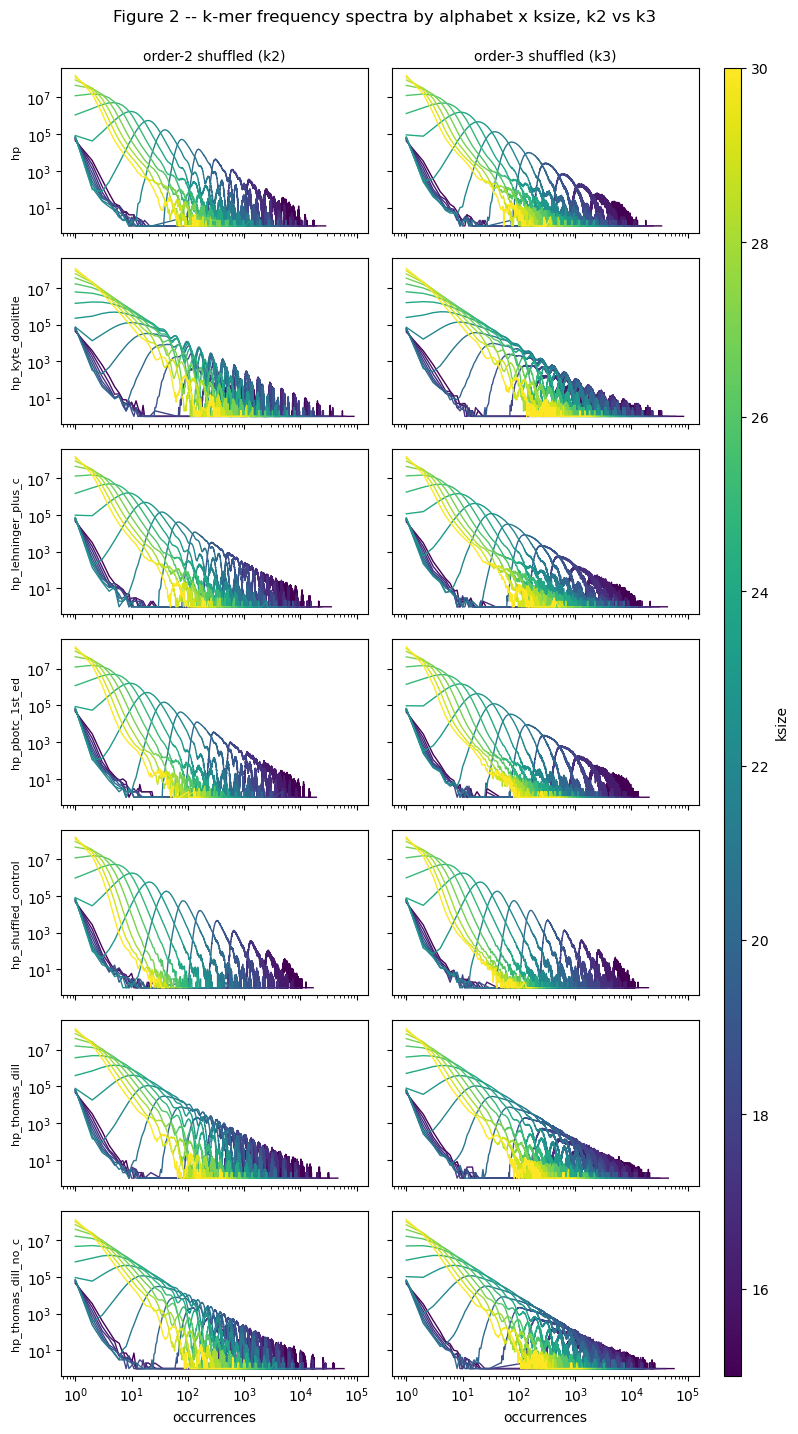

In [5]:
cmap = plt.get_cmap("viridis")
norm = plt.Normalize(vmin=min(KSIZES), vmax=max(KSIZES))

fig, axes = plt.subplots(
    len(ALPHABETS), len(DATASETS), figsize=(8.5, 2.1 * len(ALPHABETS)),
    sharex=True, sharey=True,
    gridspec_kw={"right": 0.87, "top": 0.94, "bottom": 0.05, "left": 0.12, "hspace": 0.15, "wspace": 0.08},
)

for row, alphabet in enumerate(ALPHABETS):
    for col, dataset in enumerate(DATASETS):
        ax = axes[row, col]
        sub = spectra_df.filter((pl.col("moltype") == alphabet) & (pl.col("dataset") == dataset))
        for ksize in KSIZES:
            k = sub.filter(pl.col("ksize") == ksize).sort("occurrences")
            ax.plot(k["occurrences"], k["n_kmers"], color=cmap(norm(ksize)), lw=1)
        ax.set_xscale("log")
        ax.set_yscale("log")
        if row == 0:
            ax.set_title(DATASET_LABELS[dataset], fontsize=10)
        if col == 0:
            ax.set_ylabel(alphabet, fontsize=8)

for ax in axes[-1, :]:
    ax.set_xlabel("occurrences")

fig.suptitle("Figure 2 -- k-mer frequency spectra by alphabet x ksize, k2 vs k3", fontsize=12)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.90, 0.05, 0.02, 0.89])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("ksize")

fig.savefig("/tmp/nb218_fig2_spectra_grid.png", dpi=150)


Figures 1 and 2 only show whether k2 and k3 *look* similar. Figure 3 puts a number on it:
Jensen-Shannon distance between the k2 and k3 spectra at each (alphabet, ksize) -- 0 means the
two histograms have identical shape, 1 means maximally different. This is the same distance used
in Section 2 to compare real Swiss-Prot against each null, so it also sets the noise floor for
that comparison: however far apart k2 and k3 sit from each other, by chance alone, is the
smallest distance any real-vs-null comparison should be read as meaningful.

k2-vs-k3 distance, mean across alphabets, by ksize:
shape: (16, 2)
┌───────┬──────────┐
│ ksize ┆ mean_jsd │
│ ---   ┆ ---      │
│ i64   ┆ f64      │
╞═══════╪══════════╡
│ 15    ┆ 0.322872 │
│ 16    ┆ 0.306851 │
│ 17    ┆ 0.288936 │
│ 18    ┆ 0.260211 │
│ 19    ┆ 0.22083  │
│ …     ┆ …        │
│ 26    ┆ 0.015993 │
│ 27    ┆ 0.011241 │
│ 28    ┆ 0.008939 │
│ 29    ┆ 0.007309 │
│ 30    ┆ 0.006154 │
└───────┴──────────┘

Overall range across all (alphabet, ksize) combos: 0.006 to 0.453


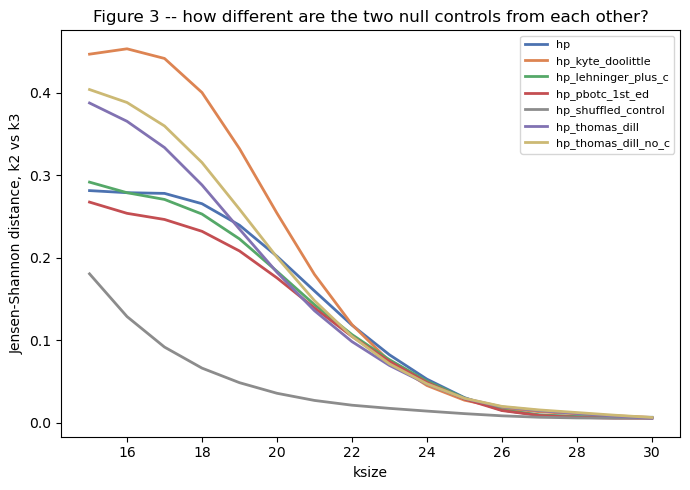

In [6]:
k2_k3_jsd_records = []
for alphabet in ALPHABETS:
    for ksize in KSIZES:
        k2_k3_jsd_records.append({
            "moltype": alphabet, "ksize": ksize,
            "jsd": spectrum_jsd(alphabet, ksize, "k2", "k3", spectra_df),
        })
k2_k3_jsd_df = pl.DataFrame(k2_k3_jsd_records)

fig, ax = plt.subplots(figsize=(7, 5))
for alphabet in ALPHABETS:
    a = k2_k3_jsd_df.filter(pl.col("moltype") == alphabet).sort("ksize")
    ax.plot(a["ksize"], a["jsd"], color=ALPHABET_COLORS[alphabet], lw=2, label=alphabet)
ax.set_xlabel("ksize")
ax.set_ylabel("Jensen-Shannon distance, k2 vs k3")
ax.set_title("Figure 3 -- how different are the two null controls from each other?")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("/tmp/nb218_fig3_k2_vs_k3_floor.png", dpi=150)

print("k2-vs-k3 distance, mean across alphabets, by ksize:")
print(k2_k3_jsd_df.group_by("ksize").agg(pl.col("jsd").mean().alias("mean_jsd")).sort("ksize"))
print(f"\nOverall range across all (alphabet, ksize) combos: {k2_k3_jsd_df['jsd'].min():.3f} to {k2_k3_jsd_df['jsd'].max():.3f}")


k2 and k3 are close to interchangeable, and get closer as ksize grows: at ksize=15 the two
nulls differ by 0.32 (Jensen-Shannon distance, averaged across alphabets), falling to 0.006 by
ksize=30. Short k-mers are more sensitive to whether the shuffle preserved dipeptide or
tripeptide statistics; once k-mers are long enough to be individually rare, that distinction
stops mattering and both nulls converge toward "every k-mer is unique." Section 2 uses this
curve as the noise floor for comparing real Swiss-Prot against the nulls, and comes back to
whether real data resembles k2 or k3 more closely.

## Section 2 -- real Swiss-Prot vs the null controls

Section 1 only compared the two nulls to each other. The question this notebook was built to
answer: at what ksize does real Swiss-Prot's k-mer spectrum start to look different from these
composition-matched nulls? Below that ksize, an HP k-mer match can't be distinguished from a
match you'd get on scrambled sequence. Above it, the match starts to reflect real biological
patterning -- conserved motifs, repeats, domains -- that shuffling destroys.

Real (unshuffled) Swiss-Prot HP-family spectra already exist at
`~/data/kmerseek-kmer-spectra/sprot.*` (same 7 alphabets, same ksize 15-30 grid, from an earlier
`main.nf --stats-only` sweep over real `uniprot_sprot.fasta.gz`), so no new pipeline run is
needed here.

In [7]:
real_dir = Path.home() / "data" / "kmerseek-kmer-spectra"
real_summaries = []
real_spectra = []
for f in sorted(real_dir.glob("sprot.*.spectrum.csv.gz")):
    moltype = f.name.split(".")[1]
    if moltype not in ALPHABET_COLORS:
        continue  # skip dayhoff/protein -- k2/k3 nulls are HP-family only
    summary, body = load_spectrum_file(f, "real")
    real_summaries.append(summary)
    real_spectra.append(body)

real_summary_df = pl.DataFrame(real_summaries).sort(["moltype", "ksize"])
real_spectra_df = pl.concat(real_spectra).sort(["moltype", "ksize", "occurrences"])
combined_spectra_df = pl.concat([spectra_df, real_spectra_df], how="diagonal_relaxed")

print(f"real_summary_df: {real_summary_df.height} (alphabet, ksize) combos")

# Is the real fasta the same corpus size as the ushuffle fastas it's compared against?
# total_kmers should match closely if ushuffle just permuted the same sequences.
corpus_check = (
    pl.concat([
        summary_df.filter(pl.col("ksize") == 15).select("dataset", "moltype", "total_kmers"),
        real_summary_df.filter(pl.col("ksize") == 15).select("dataset", "moltype", "total_kmers"),
    ])
    .pivot(values="total_kmers", index="moltype", on="dataset")
    .with_columns(((pl.col("real") - pl.col("k2")) / pl.col("k2") * 100).round(1).alias("real_vs_k2_pct"))
)
print("total_kmers at ksize=15, real vs k2 null (should match closely if the shuffled")
print("fastas are permutations of the same corpus the real spectra were built from):")
corpus_check


real_summary_df: 112 (alphabet, ksize) combos
total_kmers at ksize=15, real vs k2 null (should match closely if the shuffled
fastas are permutations of the same corpus the real spectra were built from):


moltype,k2,k3,real,real_vs_k2_pct
str,i64,i64,i64,f64
"""hp""",196771645,196344988,165059303,-16.1
"""hp_kyte_doolittle""",193231994,192915269,159920435,-17.2
"""hp_lehninger_plus_c""",196629388,196155090,164949486,-16.1
"""hp_pbotc_1st_ed""",196834749,196445980,163853420,-16.8
"""hp_shuffled_control""",197233692,196998945,171026680,-13.3
"""hp_thomas_dill""",195394297,195006057,161962395,-17.1
"""hp_thomas_dill_no_c""",194647128,194288038,161043965,-17.3


Real Swiss-Prot has 16-17% fewer `total_kmers` than either null at the same ksize. The shuffled
fastas were generated from a different, larger Swiss-Prot snapshot than the real fasta loaded
here, not an exact permutation of it. Raw counts (`unique_kmers`, `total_kmers`) aren't directly
comparable 1:1 as a result. Every metric used below is scale-normalized (a fraction, a ratio, or
a distance between normalized distributions) specifically so the comparison stays valid despite
that gap. Regenerating both real and null spectra from one identical fasta snapshot would still
be the way to firm up the exact crossover ksize found below, rather than treat it as final.

### Figure 4 -- unique k-mers and mean degeneracy: real vs null, by alphabet

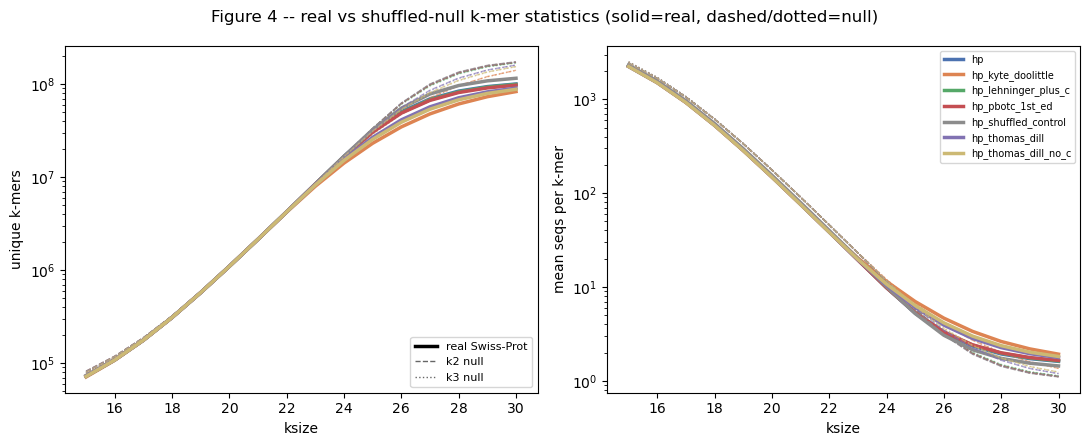

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for alphabet in ALPHABETS:
    color = ALPHABET_COLORS[alphabet]
    real_a = real_summary_df.filter(pl.col("moltype") == alphabet).sort("ksize")
    k2_a = summary_df.filter((pl.col("moltype") == alphabet) & (pl.col("dataset") == "k2")).sort("ksize")
    k3_a = summary_df.filter((pl.col("moltype") == alphabet) & (pl.col("dataset") == "k3")).sort("ksize")

    axes[0].plot(real_a["ksize"], real_a["unique_kmers"], color=color, lw=2.5, label=alphabet)
    axes[0].plot(k2_a["ksize"], k2_a["unique_kmers"], color=color, lw=1, ls="--", alpha=0.6)
    axes[0].plot(k3_a["ksize"], k3_a["unique_kmers"], color=color, lw=1, ls=":", alpha=0.6)

    axes[1].plot(real_a["ksize"], real_a["mean_seqs_per_kmer"], color=color, lw=2.5, label=alphabet)
    axes[1].plot(k2_a["ksize"], k2_a["mean_seqs_per_kmer"], color=color, lw=1, ls="--", alpha=0.6)
    axes[1].plot(k3_a["ksize"], k3_a["mean_seqs_per_kmer"], color=color, lw=1, ls=":", alpha=0.6)

for ax, ylabel in zip(axes, ["unique k-mers", "mean seqs per k-mer"]):
    ax.set_yscale("log")
    ax.set_xlabel("ksize")
    ax.set_ylabel(ylabel)

from matplotlib.lines import Line2D
style_legend = [
    Line2D([0], [0], color="black", lw=2.5, label="real Swiss-Prot"),
    Line2D([0], [0], color="black", lw=1, ls="--", alpha=0.6, label="k2 null"),
    Line2D([0], [0], color="black", lw=1, ls=":", alpha=0.6, label="k3 null"),
]
axes[0].legend(handles=style_legend, loc="lower right", fontsize=8)
axes[1].legend(loc="upper right", fontsize=7, ncol=1)

fig.suptitle("Figure 4 -- real vs shuffled-null k-mer statistics (solid=real, dashed/dotted=null)")
fig.tight_layout()
fig.savefig("/tmp/nb218_fig4_real_vs_null_summary.png", dpi=150)


### Figure 5 -- theoretical HP space (2^k) vs observed, real vs null

Each HP alphabet has exactly 2^k possible distinct k-mers of length k. At low ksize, 2^k is tiny
compared to how much sequence exists, so both real and null saturate it completely. As ksize
grows, 2^k grows exponentially while the amount of sequence stays fixed, so both curves fall
further below the theoretical ceiling. The question is whether real and null fall away from that
ceiling at the same rate.

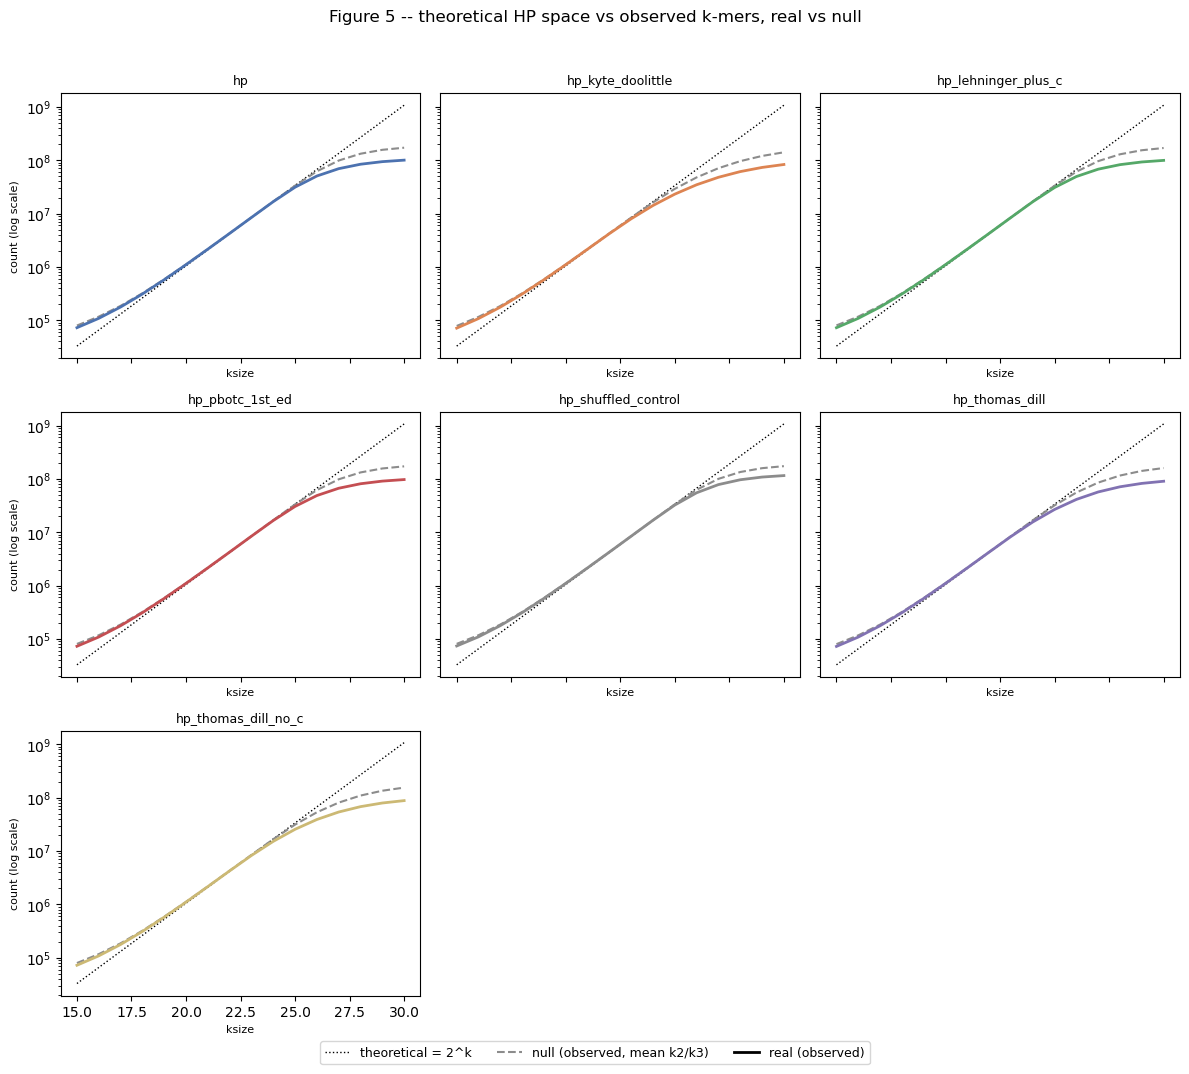

In [9]:
ncols, nrows = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.4 * nrows), sharex=True, sharey=True)
axes_flat = axes.flatten()

for ax, alphabet in zip(axes_flat, ALPHABETS):
    real_a = real_summary_df.filter(pl.col("moltype") == alphabet).sort("ksize")
    null_a = (
        summary_df.filter(pl.col("moltype") == alphabet)
        .group_by("ksize").agg(pl.col("unique_kmers").mean().alias("unique_kmers_null"))
        .sort("ksize")
    )
    theoretical = 2.0 ** real_a["ksize"].to_numpy()
    color = ALPHABET_COLORS[alphabet]

    ax.plot(real_a["ksize"], theoretical, color="black", linestyle=":", linewidth=1, label="theoretical = 2^k")
    ax.plot(null_a["ksize"], null_a["unique_kmers_null"], color="#8C8C8C", linewidth=1.5, linestyle="--", label="null (observed)")
    ax.plot(real_a["ksize"], real_a["unique_kmers"], color=color, linewidth=2, label="real (observed)")
    ax.set_yscale("log")
    ax.set_title(alphabet, fontsize=9)

for ax in axes_flat[len(ALPHABETS):]:
    ax.axis("off")
for ax in axes_flat[: len(ALPHABETS)]:
    ax.set_xlabel("ksize", fontsize=8)
for row in axes:
    row[0].set_ylabel("count (log scale)", fontsize=8)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color="black", linestyle=":", linewidth=1, label="theoretical = 2^k"),
    Line2D([0], [0], color="#8C8C8C", linewidth=1.5, linestyle="--", label="null (observed, mean k2/k3)"),
    Line2D([0], [0], color="black", linewidth=2, label="real (observed)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Figure 5 -- theoretical HP space vs observed k-mers, real vs null", y=1.02)
fig.tight_layout()
fig.savefig("/tmp/nb218_fig5_theoretical_vs_observed.png", dpi=150, bbox_inches="tight")


### Figure 6 -- negative space, real vs null

Figure 5 on a linear 0-100% "fraction of 2^k explored" axis instead of log-scale counts. Log
scale hides the size of a gap; two curves a hair's-width apart at the top of a log plot can
differ by 10x. Shaded region is real Swiss-Prot's explored/unexplored split, capped at 100%
(`unique_kmers` can slightly exceed 2^k at low ksize, see Section 1's note on non-canonical
residues). The dashed line is the null's coverage on the same axis.

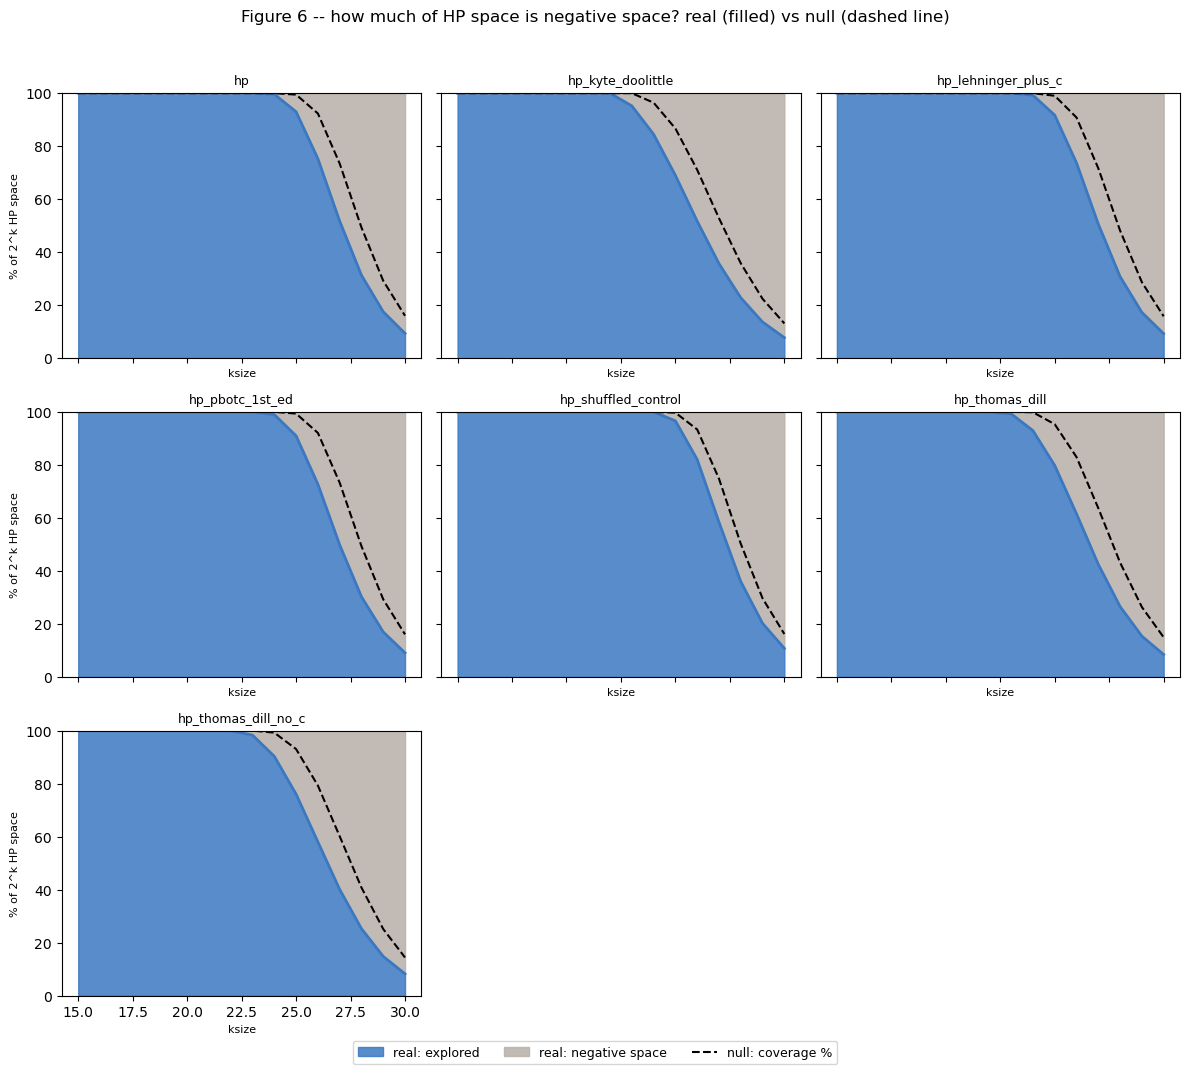

In [10]:
EXPLORED_COLOR = "#3B78C2"
NEGATIVE_SPACE_COLOR = "#B8B0A8"

ncols, nrows = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.4 * nrows), sharex=True, sharey=True)
axes_flat = axes.flatten()

for ax, alphabet in zip(axes_flat, ALPHABETS):
    real_a = real_summary_df.filter(pl.col("moltype") == alphabet).sort("ksize")
    null_a = (
        summary_df.filter(pl.col("moltype") == alphabet)
        .group_by("ksize").agg(pl.col("unique_kmers").mean().alias("unique_kmers_null"))
        .sort("ksize")
    )
    theoretical = 2.0 ** real_a["ksize"].to_numpy()
    real_pct = np.minimum(real_a["unique_kmers"].to_numpy() / theoretical * 100, 100.0)
    null_theoretical = 2.0 ** null_a["ksize"].to_numpy()
    null_pct = np.minimum(null_a["unique_kmers_null"].to_numpy() / null_theoretical * 100, 100.0)

    ax.fill_between(real_a["ksize"], 0, real_pct, color=EXPLORED_COLOR, alpha=0.85)
    ax.fill_between(real_a["ksize"], real_pct, 100, color=NEGATIVE_SPACE_COLOR, alpha=0.85)
    ax.plot(real_a["ksize"], real_pct, color=EXPLORED_COLOR, linewidth=2)
    ax.plot(null_a["ksize"], null_pct, color="black", linewidth=1.5, linestyle="--")
    ax.set_ylim(0, 100)
    ax.set_title(alphabet, fontsize=9)

for ax in axes_flat[len(ALPHABETS):]:
    ax.axis("off")
for ax in axes_flat[: len(ALPHABETS)]:
    ax.set_xlabel("ksize", fontsize=8)
for row in axes:
    row[0].set_ylabel("% of 2^k HP space", fontsize=8)

from matplotlib.patches import Patch
legend_handles = [
    Patch(color=EXPLORED_COLOR, alpha=0.85, label="real: explored"),
    Patch(color=NEGATIVE_SPACE_COLOR, alpha=0.85, label="real: negative space"),
    Line2D([0], [0], color="black", linewidth=1.5, linestyle="--", label="null: coverage %"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Figure 6 -- how much of HP space is negative space? real (filled) vs null (dashed line)", y=1.02)
fig.tight_layout()
fig.savefig("/tmp/nb218_fig6_negative_space.png", dpi=150, bbox_inches="tight")


### Figure 7 -- the crossover: real / null degeneracy ratio, by alphabet

Figures 4-6 show real and null pulling apart above ksize~25, but not the same aggregate number
each has to compare. This divides them: `ratio = real / mean(k2, k3)`. At 1.0, real looks exactly
like the composition-matched null -- no k-mer repetition beyond what shuffling alone would
produce. Above 1.0, real k-mers repeat more than the null predicts.

ksize where real crosses above null degeneracy (mean_seqs_per_kmer_ratio >= 1.0):


moltype,crossover_ksize
str,i64
"""hp""",26
"""hp_kyte_doolittle""",25
"""hp_lehninger_plus_c""",26
"""hp_pbotc_1st_ed""",26
"""hp_shuffled_control""",27
"""hp_thomas_dill""",26
"""hp_thomas_dill_no_c""",25


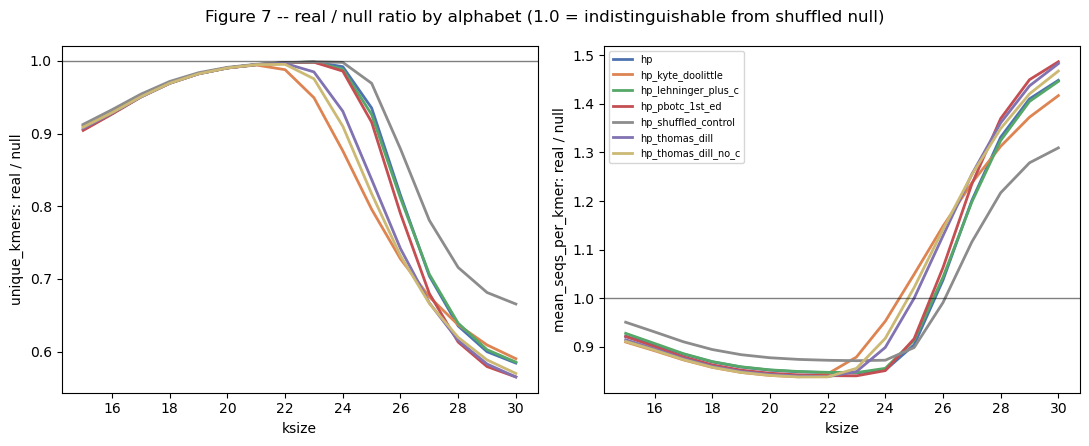

In [11]:
ratio_records = []
for alphabet in ALPHABETS:
    real_a = real_summary_df.filter(pl.col("moltype") == alphabet).sort("ksize")
    null_a = (
        summary_df.filter(pl.col("moltype") == alphabet)
        .group_by("ksize").agg(
            pl.col("unique_kmers").mean().alias("unique_kmers_null"),
            pl.col("mean_seqs_per_kmer").mean().alias("mean_seqs_per_kmer_null"),
        )
        .sort("ksize")
    )
    m = real_a.join(null_a, on="ksize")
    m = m.with_columns(
        (pl.col("unique_kmers") / pl.col("unique_kmers_null")).alias("unique_kmers_ratio"),
        (pl.col("mean_seqs_per_kmer") / pl.col("mean_seqs_per_kmer_null")).alias("mean_seqs_per_kmer_ratio"),
    )
    ratio_records.append(m.select("moltype", "ksize", "unique_kmers_ratio", "mean_seqs_per_kmer_ratio"))

ratio_df = pl.concat(ratio_records)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for alphabet in ALPHABETS:
    color = ALPHABET_COLORS[alphabet]
    a = ratio_df.filter(pl.col("moltype") == alphabet).sort("ksize")
    axes[0].plot(a["ksize"], a["unique_kmers_ratio"], color=color, lw=2, label=alphabet)
    axes[1].plot(a["ksize"], a["mean_seqs_per_kmer_ratio"], color=color, lw=2, label=alphabet)

for ax, title in zip(axes, ["unique_kmers: real / null", "mean_seqs_per_kmer: real / null"]):
    ax.axhline(1.0, color="black", lw=1, ls="-", alpha=0.5)
    ax.set_xlabel("ksize")
    ax.set_ylabel(title)
axes[1].legend(loc="upper left", fontsize=7)

fig.suptitle("Figure 7 -- real / null ratio by alphabet (1.0 = indistinguishable from shuffled null)")
fig.tight_layout()
fig.savefig("/tmp/nb218_fig7_ratio.png", dpi=150)

# The single per-alphabet number used for the rest of this notebook: first ksize where real
# overtakes null in degeneracy (mean_seqs_per_kmer_ratio >= 1.0). Below it, repeated k-mers
# are fully explained by amino-acid composition alone (null already matches or exceeds real).
# Above it, real repetition -- motifs, domains, paralogs -- starts exceeding what
# composition-matched shuffling predicts.
crossover_records = []
for alphabet in ALPHABETS:
    a = ratio_df.filter(pl.col("moltype") == alphabet).sort("ksize")
    crossed = a.filter(pl.col("mean_seqs_per_kmer_ratio") >= 1.0)
    crossover_records.append({
        "moltype": alphabet,
        "crossover_ksize": crossed["ksize"][0] if crossed.height else None,
    })
crossover_ksize_df = pl.DataFrame(crossover_records)
print("ksize where real crosses above null degeneracy (mean_seqs_per_kmer_ratio >= 1.0):")
crossover_ksize_df


The ratio crosses 1.0 at ksize 25-26 for all 6 biologically-motivated HP alphabets, and at 27
for `hp_shuffled_control`, the random-partition control. That's a tight, alphabet-independent
number: whichever biochemical scale defines H vs P barely changes it. Below ~25, a repeated HP
k-mer in real Swiss-Prot is no more common, often less, than amino-acid composition alone would
predict. Above ~25, real repetition starts exceeding what the null predicts, which is where
conserved motifs, domain reuse, and paralogous segments start contributing k-mer matches beyond
chance composition.

This is a different question from search accuracy, not a replacement for
[[feedback_best_ksize]]'s hp_pbotc_1st_ed k=19 (chosen for RBH-F1/genome-wide ranking
performance). More real motif-driven repetition is exactly the regime that inflates
paralog/low-complexity false positives (see notebook 217, `lowcomplexity_null_pipeline`
memory). ksize 25-26 is not a suggestion to raise the production ksize -- it marks the boundary
between composition-dominated and repeat-dominated regimes, useful for explaining why a match
occurs at a given ksize, not for picking a higher one.

### Figure 8 -- the occurrence CDFs behind the crossover

Figure 7's ratio compares one summary number (the mean). This plots the full occurrence
distribution each alphabet's mean was computed from, at that alphabet's own crossover ksize
(Figure 7's table) -- the cumulative % of distinct k-mers occurring at most X times, for real,
k2, and k3. How far the real line sits from the two null lines here is the same gap Figure 9
below reduces to a single Jensen-Shannon distance per ksize.

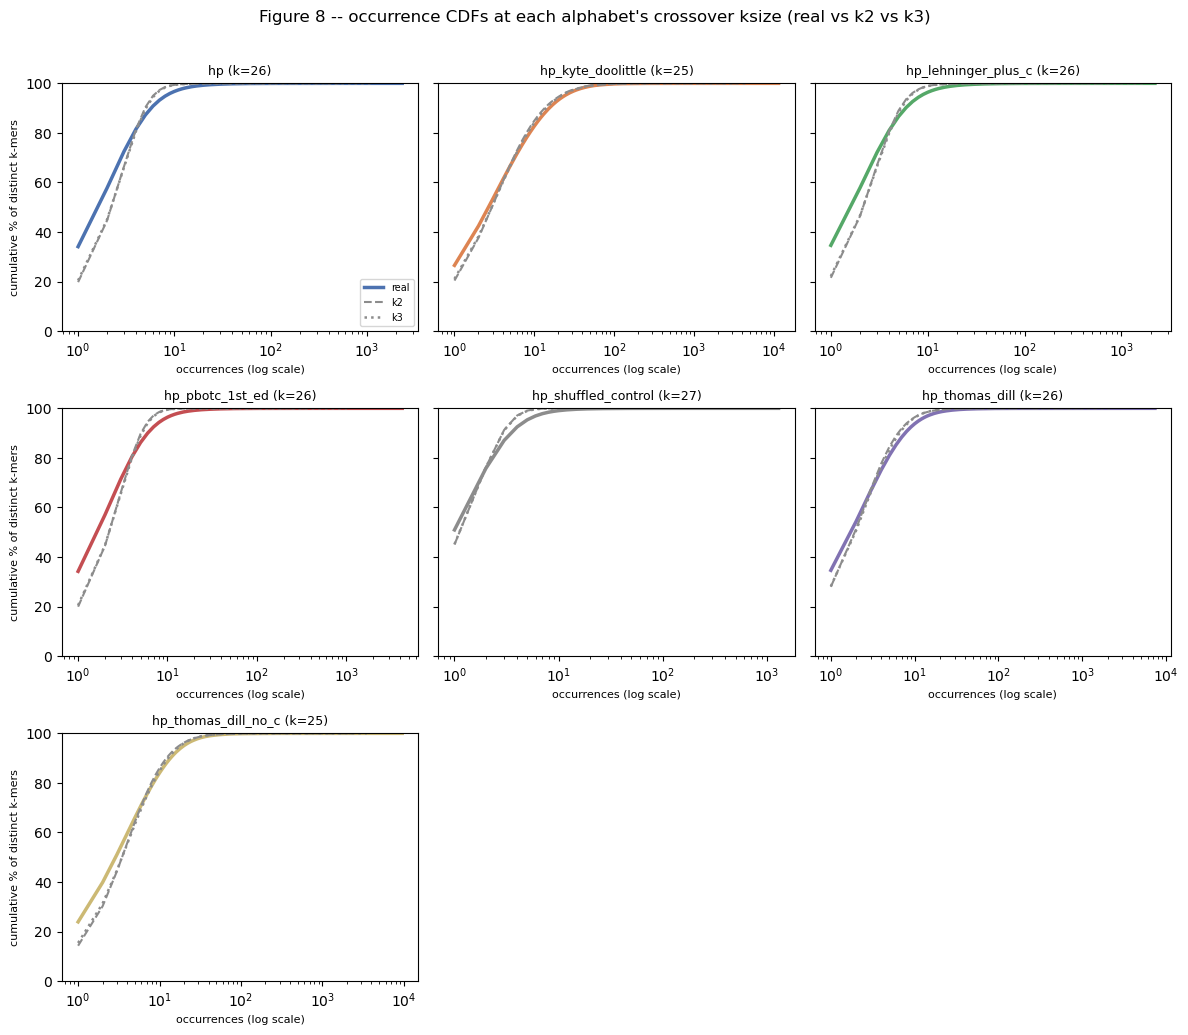

In [12]:
ncols, nrows = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.4 * nrows), sharey=True)
axes_flat = axes.flatten()

DATASET_STYLE = {
    "real": {"ls": "-", "lw": 2.5},
    "k2": {"ls": "--", "lw": 1.5},
    "k3": {"ls": ":", "lw": 1.8},
}

for ax, alphabet in zip(axes_flat, ALPHABETS):
    ksize_here = crossover_ksize_df.filter(pl.col("moltype") == alphabet)["crossover_ksize"].item()
    color = ALPHABET_COLORS[alphabet]
    for dataset in ["real", "k2", "k3"]:
        hist = (
            combined_spectra_df
            .filter((pl.col("moltype") == alphabet) & (pl.col("ksize") == ksize_here) & (pl.col("dataset") == dataset))
            .sort("occurrences")
            .with_columns((pl.col("n_kmers").cum_sum() / pl.col("n_kmers").sum() * 100).alias("cdf_pct"))
        )
        style = DATASET_STYLE[dataset]
        line_color = color if dataset == "real" else "#8C8C8C"
        ax.plot(hist["occurrences"], hist["cdf_pct"], color=line_color, linestyle=style["ls"], linewidth=style["lw"], label=dataset)
    ax.set_xscale("log")
    ax.set_ylim(0, 100)
    ax.set_title(f"{alphabet} (k={ksize_here})", fontsize=9)

for ax in axes_flat[len(ALPHABETS):]:
    ax.axis("off")
for ax in axes_flat[: len(ALPHABETS)]:
    ax.set_xlabel("occurrences (log scale)", fontsize=8)
for row in axes:
    row[0].set_ylabel("cumulative % of distinct k-mers", fontsize=8)
axes_flat[0].legend(fontsize=7, loc="lower right")

fig.suptitle("Figure 8 -- occurrence CDFs at each alphabet's crossover ksize (real vs k2 vs k3)", y=1.01)
fig.tight_layout()
fig.savefig("/tmp/nb218_fig8_cdf_at_crossover_ksize.png", dpi=150, bbox_inches="tight")


### Figure 9 -- spectrum-shape divergence (Jensen-Shannon distance) vs ksize

Figure 8 fixed one ksize per alphabet. This tracks the same Jensen-Shannon distance (real vs
the mean of k2/k3) across every ksize, against the k2-vs-k3 floor from Figure 3 -- how far
apart the two nulls sit from each other by chance alone.

Each alphabet gets two stacked panels sharing the same x-axis and the same dotted vertical
line: the top panel repeats Figure 7's ratio (the curve that actually crosses 1.0 at that
ksize), the bottom panel is the Jensen-Shannon distance at that same ksize. The vertical line
is one ksize per alphabet, read off the top panel; the bottom panel shows what the spectrum's
shape distance looks like there, not a second crossing of its own.

moltype,ksize,real_vs_k2,real_vs_k3,k2_vs_k3,real_vs_null_mean
str,i64,f64,f64,f64,f64
"""hp""",15,0.383777,0.309971,0.281518,0.346874
"""hp""",16,0.412492,0.308759,0.278987,0.360625
"""hp""",17,0.441169,0.317803,0.278132,0.379486
"""hp""",18,0.455637,0.32697,0.265623,0.391303
"""hp""",19,0.457772,0.334301,0.23956,0.396037
…,…,…,…,…,…
"""hp_thomas_dill_no_c""",26,0.084112,0.074288,0.019981,0.0792
"""hp_thomas_dill_no_c""",27,0.087993,0.082403,0.015681,0.085198
"""hp_thomas_dill_no_c""",28,0.114763,0.111234,0.012519,0.112998


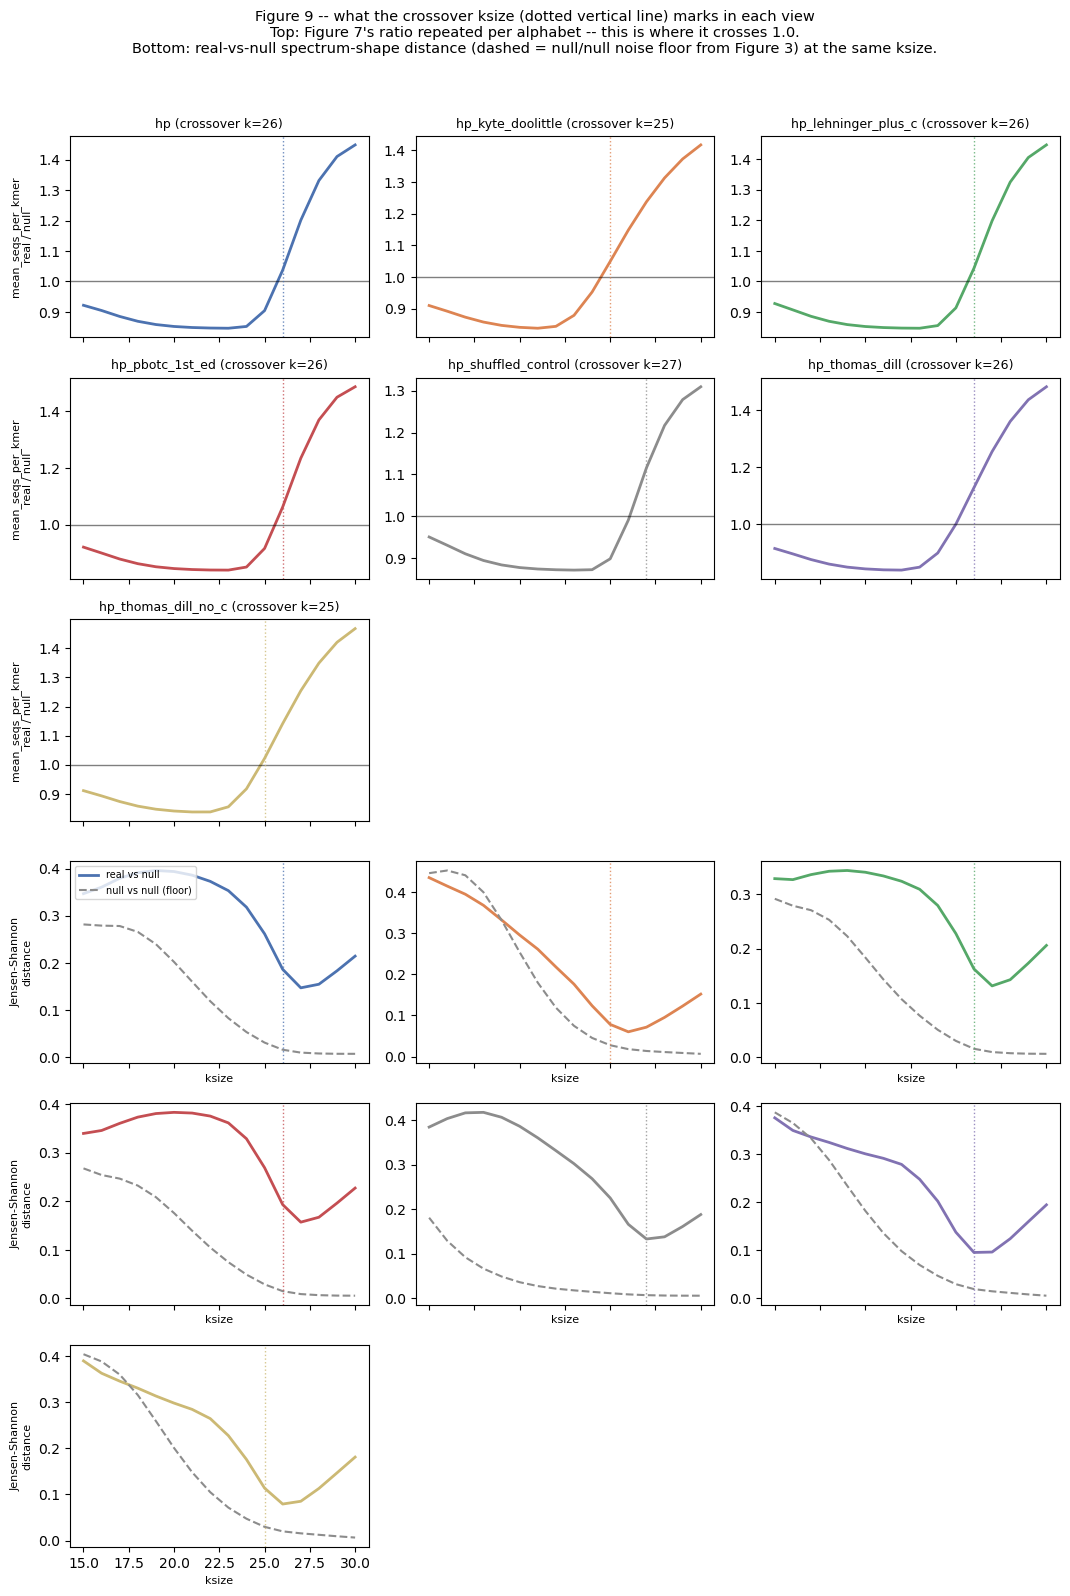

In [13]:
jsd_records = []
for alphabet in ALPHABETS:
    for ksize in KSIZES:
        jsd_records.append({
            "moltype": alphabet, "ksize": ksize,
            "real_vs_k2": spectrum_jsd(alphabet, ksize, "real", "k2", combined_spectra_df),
            "real_vs_k3": spectrum_jsd(alphabet, ksize, "real", "k3", combined_spectra_df),
            "k2_vs_k3": spectrum_jsd(alphabet, ksize, "k2", "k3", combined_spectra_df),
        })
jsd_df = pl.DataFrame(jsd_records).with_columns(
    ((pl.col("real_vs_k2") + pl.col("real_vs_k3")) / 2).alias("real_vs_null_mean")
)

ncols = 3
nrows_per_block = -(-len(ALPHABETS) // ncols)  # ceil
fig, axes = plt.subplots(
    2 * nrows_per_block, ncols, figsize=(3.6 * ncols, 2.6 * 2 * nrows_per_block), sharex=True,
)

# Top block: the mean_seqs_per_kmer ratio from Figure 7, split into one panel per alphabet
# instead of one shared panel -- repeated here, directly above the JSD panels below, so the
# "crossover ksize" the JSD block marks is visibly the same point where THIS curve crosses 1.0,
# not a number that only meant something back in Figure 7.
ratio_axes = axes[:nrows_per_block, :].flatten()
for ax, alphabet in zip(ratio_axes, ALPHABETS):
    a = ratio_df.filter(pl.col("moltype") == alphabet).sort("ksize")
    color = ALPHABET_COLORS[alphabet]
    ax.plot(a["ksize"], a["mean_seqs_per_kmer_ratio"], color=color, lw=2)
    ax.axhline(1.0, color="black", lw=1, alpha=0.5)

    crossover_k = crossover_ksize_df.filter(pl.col("moltype") == alphabet)["crossover_ksize"].item()
    if crossover_k is not None:
        ax.axvline(crossover_k, color=color, lw=1, ls=":", alpha=0.8)
    ax.set_title(f"{alphabet} (crossover k={crossover_k})", fontsize=9)
for ax in ratio_axes[len(ALPHABETS):]:
    fig.delaxes(ax)
ratio_axes[0].set_ylabel("mean_seqs_per_kmer\nreal / null", fontsize=8)
for i in range(0, len(ALPHABETS), ncols):
    ratio_axes[i].set_ylabel("mean_seqs_per_kmer\nreal / null", fontsize=8)

# Bottom block: Jensen-Shannon distance, same alphabet order, same crossover ksize marked.
jsd_axes = axes[nrows_per_block:, :].flatten()
for ax, alphabet in zip(jsd_axes, ALPHABETS):
    a = jsd_df.filter(pl.col("moltype") == alphabet).sort("ksize")
    color = ALPHABET_COLORS[alphabet]
    ax.plot(a["ksize"], a["real_vs_null_mean"], color=color, lw=2, label="real vs null")
    ax.plot(a["ksize"], a["k2_vs_k3"], color="#8C8C8C", lw=1.5, ls="--", label="null vs null (floor)")

    crossover_k = crossover_ksize_df.filter(pl.col("moltype") == alphabet)["crossover_ksize"].item()
    if crossover_k is not None:
        ax.axvline(crossover_k, color=color, lw=1, ls=":", alpha=0.8)
    ax.set_xlabel("ksize", fontsize=8)
for ax in jsd_axes[len(ALPHABETS):]:
    fig.delaxes(ax)
for i in range(0, len(ALPHABETS), ncols):
    jsd_axes[i].set_ylabel("Jensen-Shannon\ndistance", fontsize=8)
jsd_axes[0].legend(fontsize=7, loc="upper left")

fig.suptitle(
    "Figure 9 -- what the crossover ksize (dotted vertical line) marks in each view\n"
    "Top: Figure 7's ratio repeated per alphabet -- this is where it crosses 1.0.\n"
    "Bottom: real-vs-null spectrum-shape distance (dashed = null/null noise floor from Figure 3) at the same ksize.",
    y=1.02, fontsize=10.5,
)
fig.tight_layout()
fig.savefig("/tmp/nb218_fig9_jsd_vs_ksize.png", dpi=150, bbox_inches="tight")

jsd_df.sort(["moltype", "ksize"])


Real and null differ in full spectrum shape at every ksize tested, not just above the
crossover: Jensen-Shannon distance is 0.35-0.45 even at k=15, well above the k2-vs-k3 floor of
~0.2-0.3 there (for example, `median_seqs_per_kmer` at k=15 is 2.0 for real vs 1.0 for null,
Section 1's summary table). The distance then shrinks toward a minimum right around each
alphabet's crossover ksize, where real and null are as alike in shape as they get, before
widening again toward k=30.

So shape and mean tell related but different stories. The mean-degeneracy ratio (Figure 7) is a
clean U that crosses 1.0 once, at a consistent ksize. The shape distance (Figure 9) never reaches
zero and instead dips to a local minimum at roughly the same ksize the ratio crosses. Both views
point at the same ksize~25-26 as where something changes, which is why it's the most defensible
number from this analysis, even though what "changes" differs: the ratio changes sign, and the
shape distance changes direction.

### Figure 10 -- which null is real closer to, k2 or k3?

Section 1 found k2 and k3 nearly interchangeable as nulls for each other. This checks whether
that holds when compared against real data too: for each alphabet and ksize, `real_vs_k2 -
real_vs_k3` (both already computed in Figure 9). Positive means real is closer to k3; negative
means real is closer to k2.

Real is closer to k3 than k2 in 97.3% of (alphabet, ksize) combinations.

Mean (real_vs_k2 - real_vs_k3) by alphabet, across all ksizes (positive = closer to k3):


moltype,mean_k2_minus_k3
str,f64
"""hp_shuffled_control""",0.004287
"""hp_pbotc_1st_ed""",0.04796
"""hp_lehninger_plus_c""",0.055097
"""hp_thomas_dill""",0.058673
"""hp""",0.060733
"""hp_thomas_dill_no_c""",0.06602
"""hp_kyte_doolittle""",0.091812


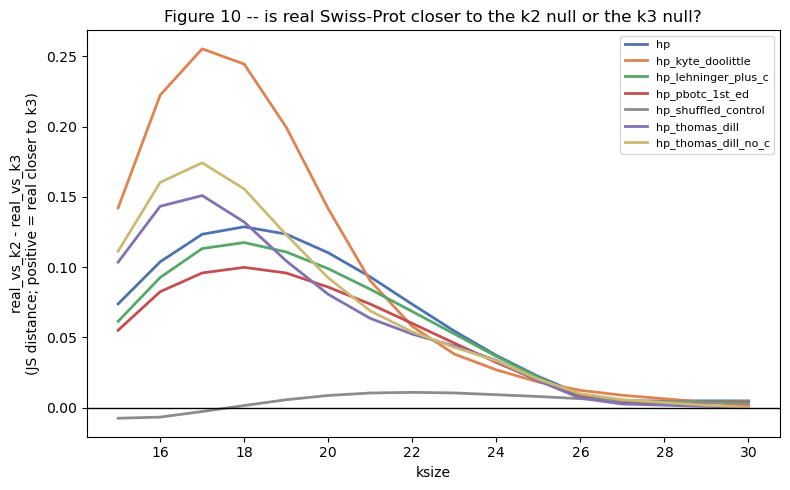

In [14]:
jsd_df = jsd_df.with_columns((pl.col("real_vs_k2") - pl.col("real_vs_k3")).alias("k2_minus_k3"))

fig, ax = plt.subplots(figsize=(8, 5))
for alphabet in ALPHABETS:
    a = jsd_df.filter(pl.col("moltype") == alphabet).sort("ksize")
    ax.plot(a["ksize"], a["k2_minus_k3"], color=ALPHABET_COLORS[alphabet], lw=2, label=alphabet)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("ksize")
ax.set_ylabel("real_vs_k2 - real_vs_k3\n(JS distance; positive = real closer to k3)")
ax.set_title("Figure 10 -- is real Swiss-Prot closer to the k2 null or the k3 null?")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("/tmp/nb218_fig10_k2_vs_k3_closeness.png", dpi=150)

closeness_df = (
    jsd_df.group_by("moltype")
    .agg(pl.col("k2_minus_k3").mean().alias("mean_k2_minus_k3"))
    .sort("mean_k2_minus_k3")
)
frac_closer_to_k3 = (jsd_df["k2_minus_k3"] > 0).mean()
print(f"Real is closer to k3 than k2 in {frac_closer_to_k3:.1%} of (alphabet, ksize) combinations.")
print("\nMean (real_vs_k2 - real_vs_k3) by alphabet, across all ksizes (positive = closer to k3):")
closeness_df


Real Swiss-Prot is closer to k3 than to k2 almost everywhere: 97.3% of (alphabet, ksize)
combinations, every alphabet on average. That makes sense given what k2 and k3 preserve: k3
(order-3, tripeptide statistics) keeps more of the real sequence's local structure than k2
(order-2, dipeptide statistics) does, so it's a better stand-in for real data by construction,
not by accident.

The gap is not just tracking the k2-vs-k3 floor down to zero at high ksize. At ksize=17, real
sits 0.13 closer to k3 than to k2, which is 45% of that ksize's floor (0.29, Figure 3) -- a
sizeable fraction of the total k2-vs-k3 difference is explained by real data pulling toward k3.
At ksize=26, the gap (0.0086) is still 54% of the floor there (0.016). The two shrink together,
but proportionally the effect holds across the whole ksize range, not just at low ksize where
everything is noisier.

Practically: k3 is the better default null when only one is needed, and the crossover ksize
found in Figure 7 barely moves if computed against k2 alone or k3 alone (25-26 either way for 6
of 7 alphabets; `hp_thomas_dill` is 25 vs k2 and 26 vs k3). The headline number in this notebook
does not depend on which null was used to get it.

## Verdict

**k2 and k3 are close to interchangeable, and get closer as ksize grows.** All 7 HP alphabets
sit in a narrow band on both nulls at every ksize (Figures 1-2). The Jensen-Shannon distance
between the two nulls' spectra (Figure 3) falls from 0.32 at ksize=15 to 0.006 at ksize=30 --
short k-mers are sensitive to whether dipeptide or tripeptide statistics were preserved, long
k-mers are individually rare enough that the distinction stops mattering. Neither null is a
better choice than the other for calibrating a null model in isolation.

**Real Swiss-Prot overtakes both nulls in k-mer degeneracy at ksize 25-26.** The mean-degeneracy
ratio (`mean_seqs_per_kmer`, real / null, Figure 7) traces a U for every alphabet: real starts
below null degeneracy at k=15 (ratio 0.91-0.95 -- real k-mers repeat *less* than composition
alone would predict), bottoms out around k=22-23 (ratio ~0.85), then crosses 1.0 at ksize 25-26
for 6 of 7 alphabets (27 for `hp_shuffled_control`) and reaches 1.3-1.5x by k=30. This crossover
is consistent across every alphabet regardless of which biochemical scale defines H vs P, and it
barely moves whether computed against k2 alone, k3 alone, or their mean (Figure 10).

Below ksize~25, a repeated HP k-mer in real Swiss-Prot is no more common, often less, than
amino-acid composition alone predicts -- the null already explains the repetition. Above it,
real repeated k-mers exceed what composition-matched shuffling predicts, which is where
conserved motifs, domain reuse, and paralogous segments start contributing matches beyond chance
composition. This answers a different question than search accuracy: it is not a replacement for
[[feedback_best_ksize]]'s hp_pbotc_1st_ed k=19 (chosen for RBH-F1/genome-wide ranking
performance). More real motif-driven repetition is exactly the regime that inflates
paralog/low-complexity false positives (notebook 217, `lowcomplexity_null_pipeline` memory), so
ksize 25-26 is not a suggestion to raise the production ksize. It marks the boundary between
composition-dominated and repeat-dominated regimes.

**Spectrum shape tells a related but distinct story.** Real and null differ in full distribution
shape at every ksize tested (Jensen-Shannon distance 0.35-0.45 even at k=15, well above the
k2-vs-k3 floor of ~0.2-0.3 there), then the distance shrinks to a local minimum right around
each alphabet's crossover ksize before widening again toward k=30 (Figure 9). The mean ratio
crosses zero once; the shape distance never reaches zero and instead dips near the same ksize.
Both views agree that ksize~25-26 is where something changes, which is why it is the most
defensible number from this analysis, even though the two metrics disagree on what "changes"
means.

**Real is consistently closer to k3 than to k2**, in 97.3% of (alphabet, ksize) combinations and
every alphabet on average (Figure 10). k3 preserves tripeptide statistics, more of real
sequence's local structure than k2's dipeptide statistics, so it is a better stand-in for real
data by construction. The gap is a substantial fraction of the k2-vs-k3 floor throughout the
ksize range (45% at k=17, 54% at k=26), not just noise that happens to shrink alongside the
floor. Despite this, the crossover ksize itself is robust to which null is used -- k3 is the
better default null when only one is needed, but the headline number in this notebook does not
depend on that choice.

**Caveat**: real (`sprot.*`) and null (`k2`/`k3`) spectra come from different Swiss-Prot
snapshots -- real has 16-17% fewer `total_kmers` at fixed ksize than either null (Section 2's
first table), not an exact shuffle of the same corpus. Every metric used to compare them is
scale-normalized to stay valid despite that gap, but regenerating both from one identical fasta
snapshot would still be the way to firm up the exact crossover ksize before treating it as
final.